# The Datasaurus

... is yet another dataset. It's a fun little dataset to compare the different graphs data with the same statiscal properties can have.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("files/datasauRus.csv")  
    
df.head(10) 

,dataset,x,y
0,dino,55.3846,97.1795
1,dino,51.5385,96.0256
2,dino,46.1538,94.4872
3,dino,42.8205,91.4103
4,dino,40.7692,88.3333
5,dino,38.7179,84.8718
6,dino,35.6410,79.8718
7,dino,33.0769,77.5641
8,dino,28.9744,74.4872
9,dino,26.1538,71.4103


Explore the dataset-field. How many unique values are there?

In [2]:
# --- Task 1: Explore Unique Datasets ---
unique_datasets = df['dataset'].unique()
print(f"Unique datasets found: {unique_datasets}")



Unique datasets found: ['dino' 'away' 'h_lines' 'v_lines' 'x_shape' 'star' 'high_lines' 'dots'
 'circle' 'bullseye' 'slant_up' 'slant_down' 'wide_lines']


First print the stats. Describe the dataframe grouped by the dataset-field.

In [3]:
# --- Task 2: Summary Statistics Loop ---
# Instead of printing the massive 14x14 matrix, let's loop through specific datasets of interest
datasets_to_check = ['dino', 'circle', 'star', 'h_lines']

print("\n--- Summary Statistics for Selected Datasets ---")
for ds in datasets_to_check:
    subset = df[df['dataset'] == ds]
    print(f"\nDataset: {ds}")
    print(f"Mean X: {subset['x'].mean():.2f}, Mean Y: {subset['y'].mean():.2f}")
    print(f"Std Dev X: {subset['x'].std():.2f}, Std Dev Y: {subset['y'].std():.2f}")
    print(f"Correlation: {subset['x'].corr(subset['y']):.2f}")




--- Summary Statistics for Selected Datasets ---

Dataset: dino
Mean X: 54.26, Mean Y: 47.83
Std Dev X: 16.77, Std Dev Y: 26.94
Correlation: -0.06

Dataset: circle
Mean X: 54.27, Mean Y: 47.84
Std Dev X: 16.76, Std Dev Y: 26.93
Correlation: -0.07

Dataset: star
Mean X: 54.27, Mean Y: 47.84
Std Dev X: 16.77, Std Dev Y: 26.93
Correlation: -0.06

Dataset: h_lines
Mean X: 54.26, Mean Y: 47.83
Std Dev X: 16.77, Std Dev Y: 26.94
Correlation: -0.06


Now create a pivot_table just showing the mean and the std for X and Y indexed on the dataset-field. Which means the dataset field appears in the rows of the pivot table.

In [4]:
df.pivot_table(index='dataset', values=['x', 'y'], aggfunc=['mean', 'std'])


mean                   std           
                    x          y          x          y
dataset                                               
away        54.266100  47.834721  16.769825  26.939743
bullseye    54.268730  47.830823  16.769239  26.935727
circle      54.267320  47.837717  16.760013  26.930036
dino        54.263273  47.832253  16.765142  26.935403
dots        54.260303  47.839829  16.767735  26.930192
h_lines     54.261442  47.830252  16.765898  26.939876
high_lines  54.268805  47.835450  16.766704  26.939998
slant_down  54.267849  47.835896  16.766759  26.936105
slant_up    54.265882  47.831496  16.768853  26.938608
star        54.267341  47.839545  16.768959  26.930275
v_lines     54.269927  47.836988  16.769959  26.937684
wide_lines  54.266916  47.831602  16.770000  26.937902
x_shape     54.260150  47.839717  16.769958  26.930002

In the pivottable you cannot add the correlation between X and Y.  So now group the dataframe again on the dataset-field.  And calculate the correlation between X and Y per dataset.

In [5]:
df.groupby('dataset')[['x', 'y']].corr().iloc[0::2, -1].reset_index(level=1, drop=True)



dataset
away         -0.064128
bullseye     -0.068586
circle       -0.068343
dino         -0.064472
dots         -0.060341
h_lines      -0.061715
high_lines   -0.068504
slant_down   -0.068980
slant_up     -0.068609
star         -0.062961
v_lines      -0.069446
wide_lines   -0.066575
x_shape      -0.065583
Name: y, dtype: float64

All numbers are pretty much the same. However, when you plot the individual observations for X and Y per datasets on a scatter, you will find out that they are completely different.

Each dataset leads to another figure. So now try to plot just the dino dataset on a scatter. You will immediately understand why this dataset is called 'dinosaurus'.

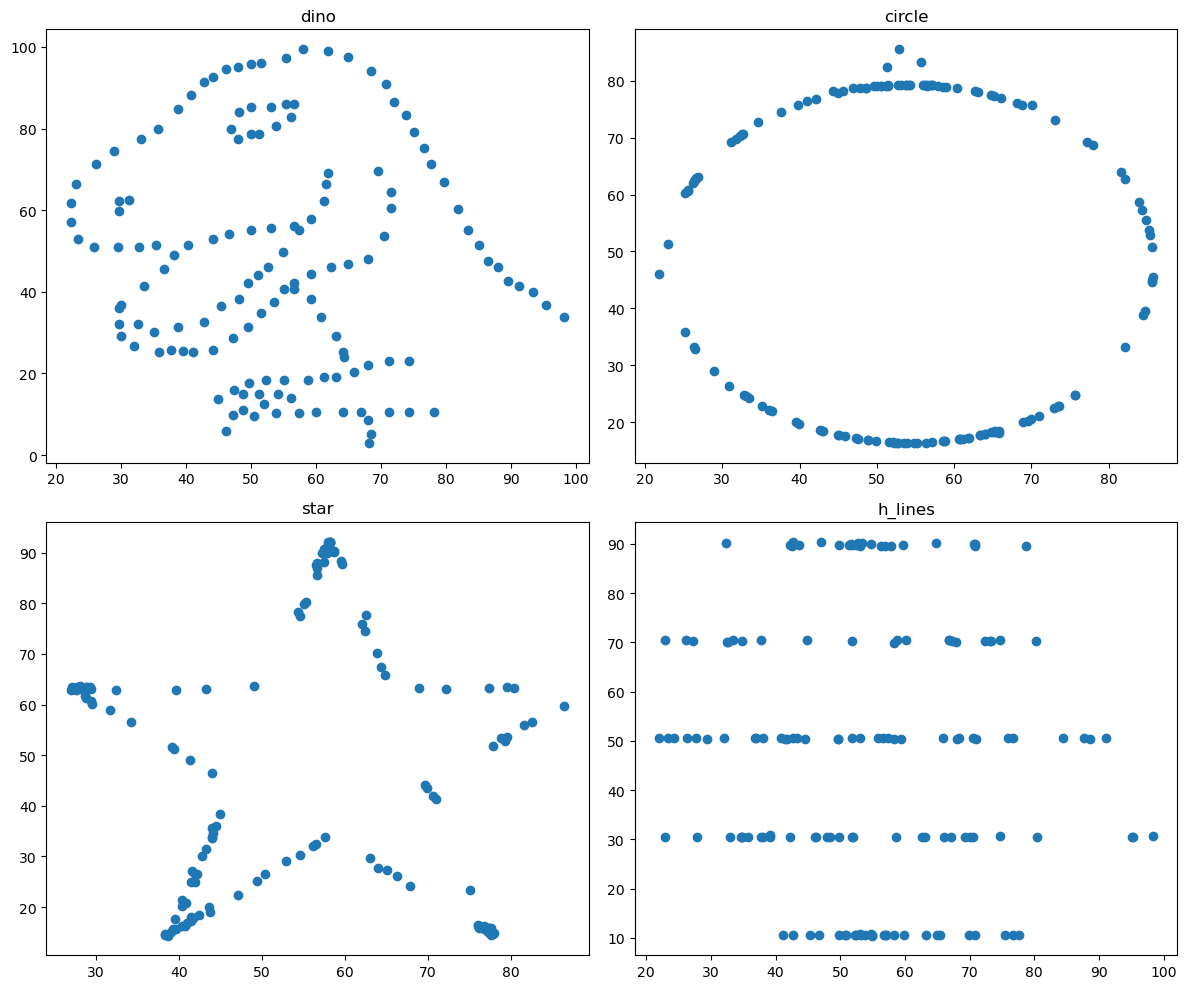

In [9]:
# --- Task 5: Visualization Loop ---
# Let's actually plot a few to prove they look different despite same stats
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

plots_to_make = ['dino', 'circle', 'star', 'h_lines']
for i, ds in enumerate(plots_to_make):
    subset = df[df['dataset'] == ds]
    axes[i].scatter(subset['x'], subset['y'], label=ds)
    axes[i].set_title(ds)
plt.tight_layout()
plt.show()


You can now try to plot all the diffent datasets on the same canvas. The code looks like this.

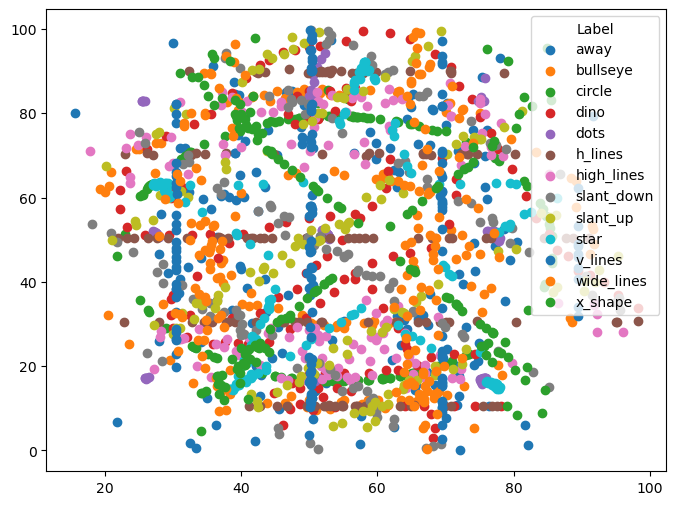

In [6]:
# plot groupby results on the same canvas 
fig, ax = plt.subplots(figsize=(8,6))

for n, grp in df.groupby('dataset'):
    ax.scatter(x = "x", y = "y", data=grp, label=n)
ax.legend(title="Label")

plt.show()

Not quite what we were after. Try to plot every group in a separate graph, all on the same canvas. There are 13 datasets.

* First use plt.subplots to create a canvas with 5 rows and 3 colums
* Next for-loop over the grouping of df on the dataset-field
* In every for-loop, add a scatterplot for the X and Y-data in the group.
    * Add it at the correct location. The following code is fun: <code>for i in range(15): print(i//3, i%3)</code>
    * You can get i by simply creating (and increasing a variable) or by enumerating the groupby
    * Try using <code>plt.cm.tab20</code> to give every graph another color!
* Delete the plots at positions 4,1 and 4,2 (13 is prime, after all)
* Show the plot

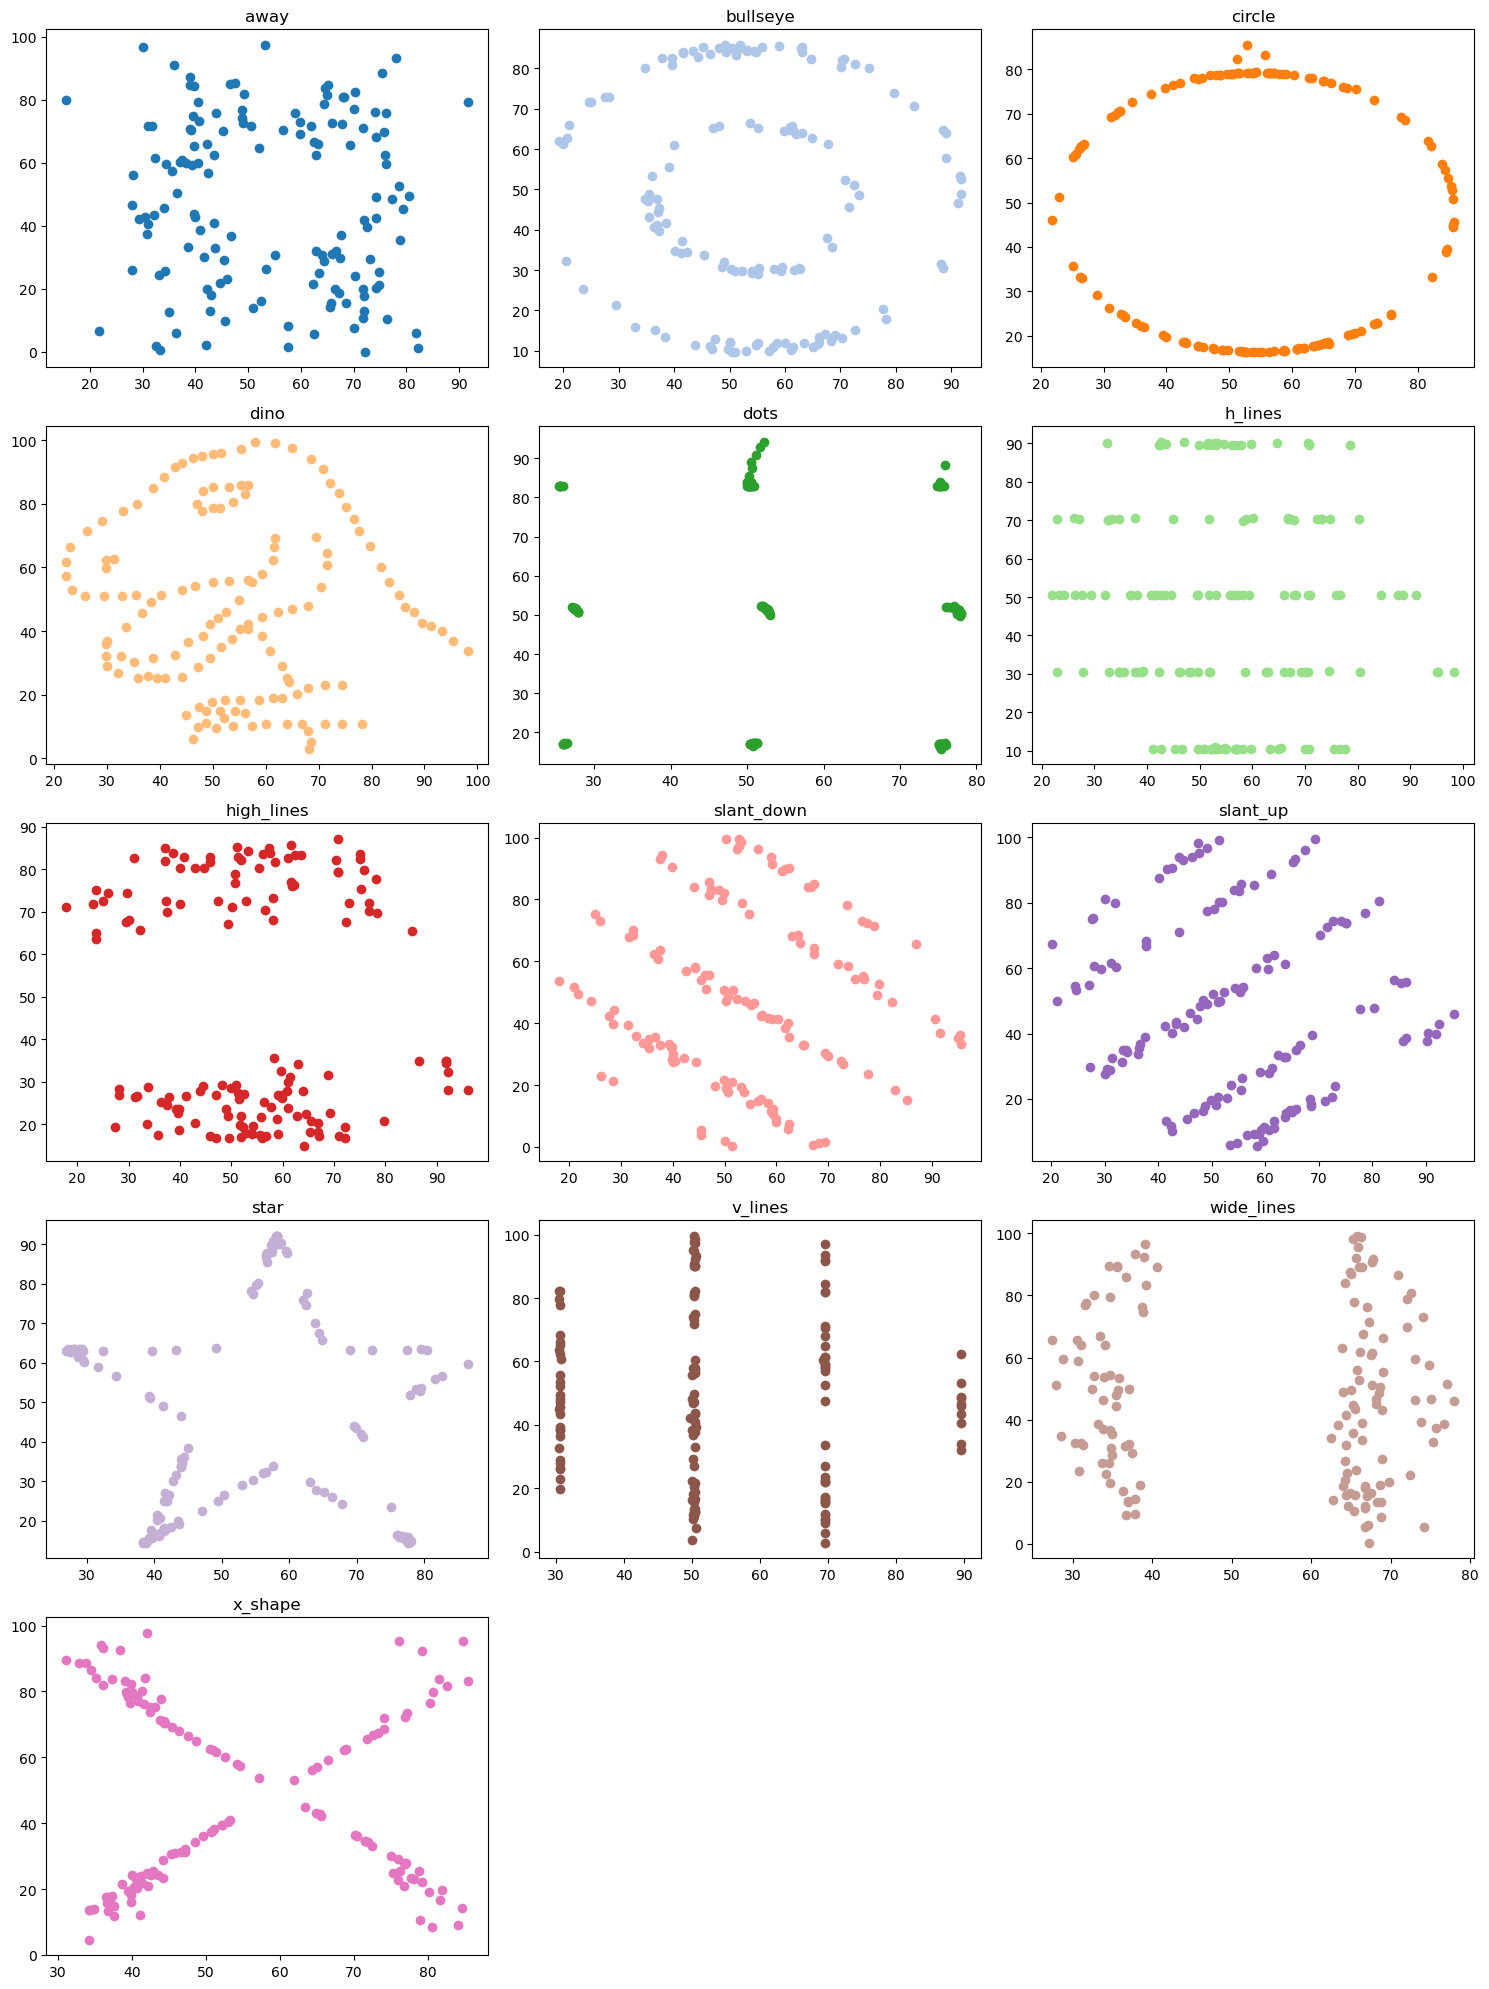

In [7]:
# Create 5x3 subplots
fig, axes = plt.subplots(5, 3, figsize=(15, 20))

# Group by the dataset field and iterate
for i, (name, grp) in enumerate(df.groupby('dataset')):
    row, col = divmod(i, 3) # Equivalent to i // 3, i % 3
    ax = axes[row, col]
    
    # Scatter using 'x' and 'y' for each group with tab20 colormap mapped to i
    ax.scatter(grp['x'], grp['y'], color=plt.cm.tab20(i), label=name)
    ax.set_title(name)

# Delete the plots at position 4,1 (14th plot) and 4,2 (15th plot)
# Using 0-indexing, 4, 1 is row 4, col 1 and 4, 2 is row 4, col 2.
fig.delaxes(axes[4, 1])
fig.delaxes(axes[4, 2])

plt.tight_layout()
plt.show()


More information on this dataset:

* https://cran.microsoft.com/snapshot/2020-08-25/web/packages/datasauRus/vignettes/Datasaurus.html
* https://github.com/perlatex/R_for_Data_Science/blob/master/demo_data/datasaurus.csv